# Hotel Dataset Clean

In [44]:
# 1. Remove leading/trailing spaces from column names
import pandas as pd
import numpy as np
df = pd.read_csv("C:\\Users\\anilr\\Downloads\\Hotel_booking_dataset - Hotel_booking_dataset.csv")
df.head()

,Booking ID,Customer Name,Booking Date,City,Room Type,Booking Channel,Customer Segment,Gender,Age,Room Nights,...,Rating,Guests,Is Member,Cancelled,Payment Method,Gross Amount,Discount Amount,Final Amount,Hotel Cost,Profit
0,BKG01888,Customer_1888,2025-05-17 00:00:00,Mumbai,Suite,Online,Premium,Male,39,4,...,1.4,2,1,0,Credit Card,31674.48,2096.850576,29577.629420,16901.386250,12676.243170
1,BKG00789,Customer_0789,2025-07-29 00:00:00,Bengaluru,Suite,Walk-in,Corporate,Male,25,1,...,2.5,2,1,0,Credit Card,4822.39,735.414475,4086.975525,2746.904163,1340.071362
2,BKG00757,Customer_0757,2025-10-19 00:00:00,Pune,Suite,Corporate,Corporate,Other,50,4,...,1.2,1,0,1,Credit Card,66334.52,15575.345300,50759.174700,40212.657470,10546.517240
3,BKG01079,Customer_1079,2025-12-14 00:00:00,Mumbai,Deluxe,Walk-in,Regular,Male,53,3,...,2.6,6,0,0,Debit Card,19255.92,5328.113064,13927.806940,9639.061764,4288.745172
4,BKG00218,Customer_0218,2025-01-20 00:00:00,Delhi,Suite,Travel Agent,Budget,Male,38,NaN,...,4.2,4,1,0,Cash,15685.38,5160.490020,10524.889980,6545.581304,3979.308676


In [45]:
import pandas as pd
import numpy as np

df = pd.read_csv(r"C:\Users\anilr\Downloads\Hotel_booking_dataset - Hotel_booking_dataset.csv")
df.head()

df.columns = df.columns.str.strip().str.replace(" ", "_", regex=True)

df.head(1)

,Booking_ID,Customer_Name,Booking_Date,City,Room_Type,Booking_Channel,Customer_Segment,Gender,Age,Room_Nights,...,Rating,Guests,Is_Member,Cancelled,Payment_Method,Gross_Amount,Discount_Amount,Final_Amount,Hotel_Cost,Profit
0,BKG01888,Customer_1888,2025-05-17 00:00:00,Mumbai,Suite,Online,Premium,Male,39,4,...,1.4,2,1,0,Credit Card,31674.48,2096.850576,29577.62942,16901.38625,12676.24317


In [46]:
# 2. Standardize all date formats into one consistent format (YYYY-MM-DD)
df["Booking_Date"] = pd.to_datetime(df["Booking_Date"],errors="coerce").dt.strftime("%Y-%m-%d")
df["Booking_Date"].isna().sum()
df["Booking_Date"] = df["Booking_Date"].fillna(pd.Timestamp("2026-08-19"))
df["Booking_Date"].isna().sum()


np.int64(0)

In [47]:
# 3. Handle completely missing Customer Name values
df['Customer_Name'].isnull().sum()
df['Customer_Name'].dropna(inplace = True)
df['Customer_Name']

0       Customer_1888
1       Customer_0789
2       Customer_0757
3       Customer_1079
4       Customer_0218
            ...      
2020    Customer_1738
2021    Customer_1193
2022    Customer_1210
2023    Customer_1060
2024    Customer_0642
Name: Customer_Name, Length: 2025, dtype: object

In [48]:
# 4. Fix inconsistent Gender values
df['Gender'] = df['Gender'].replace({"F":"Female",
                                    "FEMALE":"Female",
                                    "female":"Female",
                                    "M":"Male",
                                     "male":"Male",
                                     "MALE":"Male"
                                    })
df['Gender'].unique()

array(['Male', 'Other', 'Female'], dtype=object)

In [49]:
# 5. Clean and standardize City names
df['City'] = df['City'].replace({"mumbai":"Mumbai",
                                 "MUMBAI":"Mumbai",
                                 "bangalore":"Bengaluru",
                                 "Bangalore":"Bengaluru",
                                 "Hyderabad":"Hydrabad",
                                 "Delhi":"delhi",
                                 "nan":"Mumbai",
                                })

df['City'].unique()

array(['Mumbai', 'Bengaluru', 'Pune', 'delhi', 'Chennai', 'Hydrabad', nan],
      dtype=object)

In [50]:
# 6. Standardize Room Type categories
df['Room_Type'] = df['Room_Type'].replace({"suite":"Suite",
                                 "standard":"Standard",
                                 "STANDARD":"Standard",
                                 "delux":"Deluxe",
                                 "Unknown":"nan",
                                           'nan':"nan"
                                })
df['Room_Type'].unique()

array(['Suite', 'Deluxe', 'Standard', 'Executive', nan, 'exec', 'nan'],
      dtype=object)

In [51]:
# 7. Clean Booking Channel values
df['Booking_Channel'] = df['Booking_Channel'].replace({"online":"Online",
                                 "ONLINE":"Online",
                                 "TravelAgent":"Travel Agent",
                                 "travel agent":"Travel Agent",
                                 "TravelAgent":"Travel Agent",
                                 "corp":"Corporate"
                                })
df['Booking_Channel'].unique()

array(['Online', 'Walk-in', 'Corporate', 'Travel Agent', 'walkin'],
      dtype=object)

In [52]:
# 8. Standardize Customer Segment
df['Customer_Segment'] = df['Customer_Segment'].replace({"premium":"Premium",
                                 "corporate":"Corporate",
                                 "regular":"Regular",
                                 "REG":"Regular",
                                 "budget":"Budget"

                                })
df['Customer_Segment'].unique()

array(['Premium', 'Corporate', 'Regular', 'Budget', 'VIP'], dtype=object)

In [53]:
# 9. Fix Age column (invalid and non-numeric values)

df['Age'] = df['Age'].astype(str).str.extract(r'(\d+)')[0]

df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

df.loc[(df['Age'] < 18) | (df['Age'] > 100), 'Age'] = np.nan
df['Age'] = df['Age'].astype('Int64')

print(df['Age'].unique())

<IntegerArray>
[  39,   25,   50,   53,   38,   35,   33,   65,   48,   47,   52,   44, <NA>,
   29,   49,   34,   58,   42,   19,   28,   62,   64,   21,   26,   57,   22,
   59,   54,   46,   31,   67,   24,   68,   32,   27,   56,   36,   61,  100,
   60,   43,   20,   66,   51,   30,   40,   18,   23,   63,   45,   69,   41,
   37,   55]
Length: 54, dtype: Int64


In [54]:
# 10. Clean Room Nights column
df['Room_Nights'] = df['Room_Nights'].replace({"two":2,
                                 "5 days":5,
                                 "100":10,
                                 "50":5,
                                 "3 nights":3

                                })
df['Room_Nights'] = pd.to_numeric(df['Room_Nights'], errors='coerce')
df['Room_Nights'] = df['Room_Nights'].fillna(df['Room_Nights'].mean())
df['Room_Nights'].unique()

array([ 4.        ,  1.        ,  3.        ,  4.11039604,  2.        ,
        5.        , 10.        ,  7.        ,  6.        , 30.        ])

In [55]:
# 11. Fix Room Rate (mixed formats and extreme values)
df['Rating'] = df['Rating'].replace({"4 stars":4,
                                 "good":4,
                                 "5/5":5,
                                 "6":5,
                                 "9":5

                                })
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')
df['Rating'] = df['Rating'].fillna(df['Rating'].mean())
df['Rating'].unique()

array([1.4       , 2.5       , 1.2       , 2.6       , 4.2       ,
       3.05430297, 3.6       , 2.3       , 4.1       , 4.5       ,
       4.6       , 2.8       , 2.4       , 4.8       , 2.9       ,
       2.7       , 4.        , 1.        , 1.8       , 3.8       ,
       1.5       , 3.7       , 1.7       , 3.        , 2.1       ,
       1.1       , 1.9       , 3.2       , 1.6       , 1.3       ,
       3.4       , 2.2       , 3.5       , 4.4       , 4.9       ,
       4.7       , 5.        , 3.1       , 3.9       , 4.3       ,
       2.        , 3.3       , 0.        ])

In [56]:
# 12. Clean Discount % column
df['Discount_%'] = pd.to_numeric(df['Discount_%'], errors='coerce')
df['Discount_%'].unique()

array([ 6.62, 15.25, 23.48, ..., 34.26, 29.05, 13.41], shape=(1478,))

In [57]:
# 13. Handle missing and invalid Rating values

df['Rating'] = df['Rating'].fillna(df['Rating'].mean())
df['Rating'].unique()

array([1.4       , 2.5       , 1.2       , 2.6       , 4.2       ,
       3.05430297, 3.6       , 2.3       , 4.1       , 4.5       ,
       4.6       , 2.8       , 2.4       , 4.8       , 2.9       ,
       2.7       , 4.        , 1.        , 1.8       , 3.8       ,
       1.5       , 3.7       , 1.7       , 3.        , 2.1       ,
       1.1       , 1.9       , 3.2       , 1.6       , 1.3       ,
       3.4       , 2.2       , 3.5       , 4.4       , 4.9       ,
       4.7       , 5.        , 3.1       , 3.9       , 4.3       ,
       2.        , 3.3       , 0.        ])

In [58]:
# 14. Clean Guests column (extreme values)
df.loc[(df['Guests'] < 1) | (df['Guests'] > 6), 'Guests'] = np.nan
df['Guests'] = df['Guests'].fillna(df['Guests'].mean())
df['Guests'].unique()

array([2.        , 1.        , 6.        , 4.        , 3.        ,
       5.        , 3.48457711])

In [59]:
# 15. Standardize Is Member column
df['Is_Member'] = df['Is_Member'].replace({"1":"Yes",
                                 "0":"No",
                                 "Y":"Yes",
                                 "N":"No",
                                 "Non-Member":"No",
                                           "Member":"Yes"

                                })
df['Is_Member'].unique()

array(['Yes', 'No'], dtype=object)

In [60]:
# 16. Standardize Cancelled column
df['Cancelled'] = df['Cancelled'].replace({"1":"Yes",
                                 "0":"No",
                                 "Y":"Yes",
                                 "N":"No",
                                 "Not Cancelled":"No",
                                           "Cancelled":"Yes"

                                })
df['Cancelled'].unique()

array(['No', 'Yes'], dtype=object)

In [61]:
# 17. Clean Payment Method values
df['Payment_Method'] = df['Payment_Method'].replace({"CreditCard":"Credit Card",
                                 "credit card":"Credit Card",
                                 "netbanking":"Net Banking",
                                 "upi":"UPI",
                                 "cash":"Cash",
                                })
df['Guests'] = df['Guests'].fillna(df['Guests'].median())
df['Payment_Method'].unique()

array(['Credit Card', 'Debit Card', 'Cash', 'UPI', 'Net Banking', nan],
      dtype=object)

In [62]:
# 18. Remove or flag duplicate Booking IDs
df['Booking_ID'] = df['Booking_ID'].fillna(df['Booking_ID'].mode())

In [63]:
# 19. Handle missing Room Type values
df['Room_Type'] = df['Room_Type'].fillna(df['Room_Type'].mode())
df['Room_Type'].unique()

array(['Suite', 'Deluxe', 'Standard', 'Executive', nan, 'exec', 'nan'],
      dtype=object)

In [64]:
# 20. Fix inconsistent Final Amount calculations

df['Final_Amount'] = df['Final_Amount'].fillna(df['Final_Amount'].median())
df['Final_Amount'].unique()

array([29577.62942 ,  4086.975525, 50759.1747  , ..., 56438.28432 ,
       12130.83564 ,  6619.502435], shape=(1970,))

In [65]:
# 21. Clean Customer Name (placeholder and invalid names)
df['Customer_Name'] = df['Customer_Name'].replace({"N/A":"Unknown",
                                                   "NA":"Unknown",
                                                   "n/a":"Unknown",
                                                   "Unknown":"Unknown",
                                                   "":"Unknown",
                                                   "12345":"Unknown"
                                })
df['Customer_Name']

0       Customer_1888
1       Customer_0789
2       Customer_0757
3       Customer_1079
4       Customer_0218
            ...      
2020    Customer_1738
2021    Customer_1193
2022    Customer_1210
2023    Customer_1060
2024    Customer_0642
Name: Customer_Name, Length: 2025, dtype: object

In [66]:
# 22. Convert all numeric columns to proper numeric data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2025 entries, 0 to 2024
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Booking_ID        2025 non-null   object 
 1   Customer_Name     1991 non-null   object 
 2   Booking_Date      2025 non-null   object 
 3   City              1996 non-null   object 
 4   Room_Type         1994 non-null   object 
 5   Booking_Channel   2025 non-null   object 
 6   Customer_Segment  2025 non-null   object 
 7   Gender            2025 non-null   object 
 8   Age               1974 non-null   Int64  
 9   Room_Nights       2025 non-null   float64
 10  Room_Rate         1995 non-null   object 
 11  Discount_%        1970 non-null   float64
 12  Rating            2025 non-null   float64
 13  Guests            2025 non-null   float64
 14  Is_Member         2025 non-null   object 
 15  Cancelled         2025 non-null   object 
 16  Payment_Method    1995 non-null   object 


In [67]:
# 23. Handle missing values in key financial columns (Gross Amount, Discount Amount, Final Amount, Profit)
df['Gross_Amount'] = df['Gross_Amount'].fillna(df['Gross_Amount'].median())
df['Discount_Amount'] = df['Discount_Amount'].fillna(df['Discount_Amount'].median())
df['Final_Amount'] = df['Final_Amount'].fillna(df['Final_Amount'].median())
df['Profit'] = df['Profit'].fillna(df['Profit'].median())
print(df['Gross_Amount'])
print(df['Discount_Amount'])
print(df['Final_Amount'])
print(df['Profit'])
df

0       31674.48
1        4822.39
2       66334.52
3       19255.92
4       15685.38
          ...   
2020    12777.78
2021    51298.55
2022    79546.56
2023    18041.10
2024     7644.65
Name: Gross_Amount, Length: 2025, dtype: float64
0        2096.850576
1         735.414475
2       15575.345300
3        5328.113064
4        5160.490020
            ...     
2020      204.444480
2021    17574.883230
2022    23108.275680
2023     5910.264360
2024     1025.147565
Name: Discount_Amount, Length: 2025, dtype: float64
0       29577.629420
1        4086.975525
2       50759.174700
3       13927.806940
4       10524.889980
            ...     
2020    12573.335520
2021    33723.666770
2022    56438.284320
2023    12130.835640
2024     6619.502435
Name: Final_Amount, Length: 2025, dtype: float64
0       12676.243170
1        1340.071362
2       10546.517240
3        4288.745172
4        3979.308676
            ...     
2020     3295.541467
2021    11415.688440
2022    19894.152600
2023     244

,Booking_ID,Customer_Name,Booking_Date,City,Room_Type,Booking_Channel,Customer_Segment,Gender,Age,Room_Nights,...,Rating,Guests,Is_Member,Cancelled,Payment_Method,Gross_Amount,Discount_Amount,Final_Amount,Hotel_Cost,Profit
0,BKG01888,Customer_1888,2025-05-17,Mumbai,Suite,Online,Premium,Male,39,4.000000,...,1.4,2.0,Yes,No,Credit Card,31674.48,2096.850576,29577.629420,16901.386250,12676.243170
1,BKG00789,Customer_0789,2025-07-29,Bengaluru,Suite,Walk-in,Corporate,Male,25,1.000000,...,2.5,2.0,Yes,No,Credit Card,4822.39,735.414475,4086.975525,2746.904163,1340.071362
2,BKG00757,Customer_0757,2025-10-19,Pune,Suite,Corporate,Corporate,Other,50,4.000000,...,1.2,1.0,No,Yes,Credit Card,66334.52,15575.345300,50759.174700,40212.657470,10546.517240
3,BKG01079,Customer_1079,2025-12-14,Mumbai,Deluxe,Walk-in,Regular,Male,53,3.000000,...,2.6,6.0,No,No,Debit Card,19255.92,5328.113064,13927.806940,9639.061764,4288.745172
4,BKG00218,Customer_0218,2025-01-20,delhi,Suite,Travel Agent,Budget,Male,38,4.110396,...,4.2,4.0,Yes,No,Cash,15685.38,5160.490020,10524.889980,6545.581304,3979.308676
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020,BKG01738,Customer_1738,2025-11-27,Hydrabad,Deluxe,Online,Premium,Other,52,3.000000,...,4.0,4.0,Yes,No,Net Banking,12777.78,204.444480,12573.335520,9277.794053,3295.541467
2021,BKG01193,Customer_1193,2025-10-22,Hydrabad,Deluxe,Online,Premium,Male,33,5.000000,...,4.7,5.0,Yes,Yes,Net Banking,51298.55,17574.883230,33723.666770,22307.978330,11415.688440
2022,BKG01210,Customer_1210,2025-07-11,Mumbai,Deluxe,Online,Premium,Male,48,6.000000,...,1.3,6.0,Yes,No,Debit Card,79546.56,23108.275680,56438.284320,36544.131720,19894.152600
2023,BKG01060,Customer_1060,2025-01-24,Hydrabad,Executive,Travel Agent,Budget,Female,52,2.000000,...,3.8,2.0,Yes,Yes,Debit Card,18041.10,5910.264360,12130.835640,9683.417958,2447.417682


In [68]:
# 24. Remove rows with completely invalid dates

df["Booking_Date"] = pd.to_datetime(df["Booking_Date"],errors="coerce")
df = df.dropna(subset=["Booking_Date"])

print(df["Booking_Date"].head())
print(df["Booking_Date"].isna().sum())
print(df["Booking_Date"].value_counts())

0   2025-05-17
1   2025-07-29
2   2025-10-19
3   2025-12-14
4   2025-01-20
Name: Booking_Date, dtype: datetime64[ns]
0
Booking_Date
2026-08-19    30
2025-01-10    14
2025-01-04    13
2025-05-08    12
2025-08-08    12
              ..
2025-07-23     1
2025-09-26     1
2025-11-12     1
2025-01-27     1
2025-01-17     1
Name: count, Length: 366, dtype: int64


In [69]:
# 25. Standardize boolean-like columns (Is Member and Cancelled) to the same format
# 25. Standardize boolean-like columns

boolean_columns = ["Is_Member", "Cancelled"]

for col in boolean_columns:
    df[col] = df[col].astype(str).str.strip().str.lower()

    df[col] = df[col].replace({
        "yes": True,
        "y": True,
        "true": True,
        "1": True,
        "no": False,
        "n": False,
        "false": False,
        "0": False
    })

print(df[boolean_columns].head())

   Is_Member  Cancelled
0       True      False
1       True      False
2      False       True
3      False      False
4       True      False


C:\Users\anilr\AppData\Local\Temp\ipykernel_18692\1595558838.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace({
C:\Users\anilr\AppData\Local\Temp\ipykernel_18692\1595558838.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace({


In [70]:
# 26. Trim extra spaces from all text columns
# 26. Trim extra spaces from all text columns

text_columns = df.select_dtypes(include="object").columns

for col in text_columns:
    df[col] = df[col].str.strip()

print(df.head(10))

  Booking_ID  Customer_Name Booking_Date       City  Room_Type  \
0   BKG01888  Customer_1888   2025-05-17     Mumbai      Suite   
1   BKG00789  Customer_0789   2025-07-29  Bengaluru      Suite   
2   BKG00757  Customer_0757   2025-10-19       Pune      Suite   
3   BKG01079  Customer_1079   2025-12-14     Mumbai     Deluxe   
4   BKG00218  Customer_0218   2025-01-20      delhi      Suite   
5   BKG00952  Customer_0952   2025-11-06      delhi   Standard   
6   BKG00282  Customer_0282   2026-08-19  Bengaluru      Suite   
7   BKG01278  Customer_1278   2025-12-24      delhi   Standard   
8   BKG00386  Customer_0386   2025-07-15  Bengaluru     Deluxe   
9   BKG00112  Customer_0112   2025-03-05     Mumbai  Executive   

  Booking_Channel Customer_Segment  Gender  Age  Room_Nights  ...    Rating  \
0          Online          Premium    Male   39     4.000000  ...  1.400000   
1         Walk-in        Corporate    Male   25     1.000000  ...  2.500000   
2       Corporate        Corporate  

In [71]:
# 27. Fix extreme or impossible Age values
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Age'].unique()

<IntegerArray>
[ 39,  25,  50,  53,  38,  35,  33,  65,  48,  47,  52,  44,  29,  49,  34,
  58,  42,  19,  28,  62,  64,  21,  26,  57,  22,  59,  54,  46,  31,  67,
  24,  68,  32,  27,  56,  36,  61, 100,  60,  43,  20,  66,  51,  30,  40,
  18,  23,  63,  45,  69,  41,  37,  55]
Length: 53, dtype: Int64

In [72]:
# 28. Handle missing Gender values
df['Gender'].isna().sum()

np.int64(0)

In [73]:
# 29. Correct obvious typos in categorical columns
for col in df.select_dtypes(include="object").columns:
    print(col)
df[col].unique()

Booking_ID
Customer_Name
City
Room_Type
Booking_Channel
Customer_Segment
Gender
Room_Rate
Payment_Method


array(['Credit Card', 'Debit Card', 'Cash', 'UPI', 'Net Banking', nan],
      dtype=object)

In [74]:
# 30. Decide how to treat rows with too many missing values
df.isna().sum()
df= df.dropna()
df.isna().sum()

Booking_ID          0
Customer_Name       0
Booking_Date        0
City                0
Room_Type           0
Booking_Channel     0
Customer_Segment    0
Gender              0
Age                 0
Room_Nights         0
Room_Rate           0
Discount_%          0
Rating              0
Guests              0
Is_Member           0
Cancelled           0
Payment_Method      0
Gross_Amount        0
Discount_Amount     0
Final_Amount        0
Hotel_Cost          0
Profit              0
dtype: int64

# Matplotlib + Seaborn questions based on the hotel booking dataset.

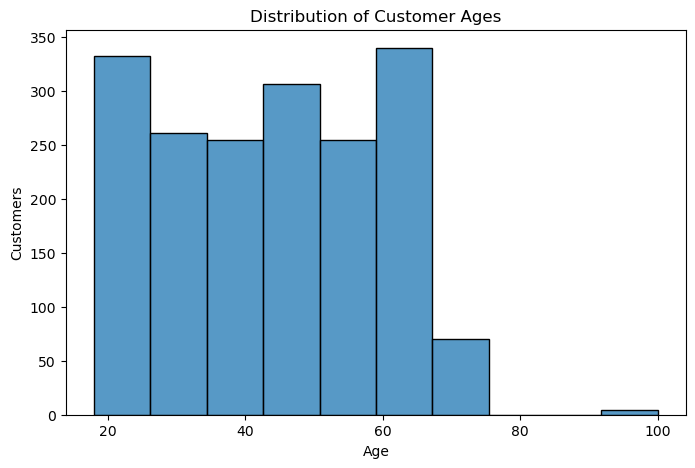

In [75]:
#1. Histogram of Age
#What to plot: Distribution of customer ages
#Columns: Age
#Required: Age should be numeric and cleaned (remove text like “30 yrs”, impossible values)

#Easy explanation: Shows how many customers fall in different age groups (young, middle-
#aged, old).

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Age",
    bins= 10
)

plt.title("Distribution of Customer Ages")
plt.xlabel("Age")
plt.ylabel("Customers")
plt.show()

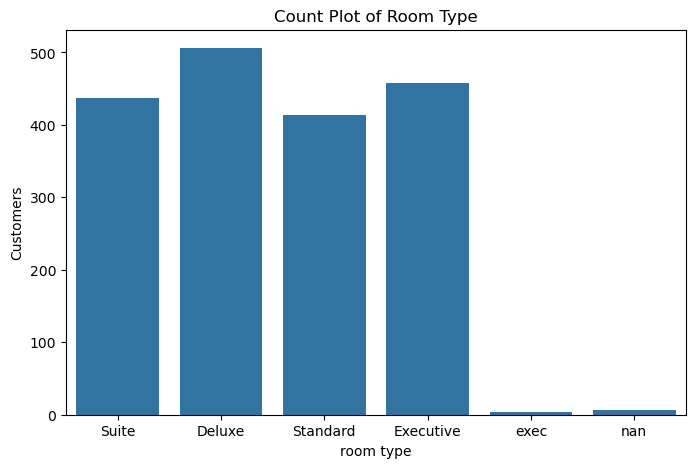

In [76]:
#2. Count Plot of Room Type
#What to plot: Number of bookings for each room type
#Columns: Room Type
#Required: Room Type cleaned and standardized (Deluxe, Suite, Standard, Executive)
#Easy explanation: Quickly tells which room type is booked the most.
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Room_Type"
)

plt.title("Count Plot of Room Type")
plt.xlabel("room type")
plt.ylabel("Customers")
plt.show()

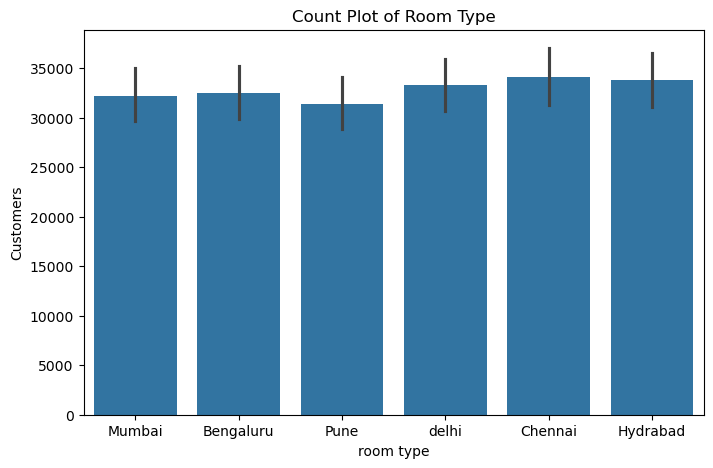

In [77]:
#3. Bar Plot of Average Final Amount by City
#What to plot: Average spending (Final Amount) in each city
#Columns: City, Final Amount
#Required: City cleaned, Final Amount numeric
#Easy explanation: Shows which city generates higher average revenue.
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="City",
    y = "Final_Amount"
)

plt.title("Count Plot of Room Type")
plt.xlabel("room type")
plt.ylabel("Customers")
plt.show()

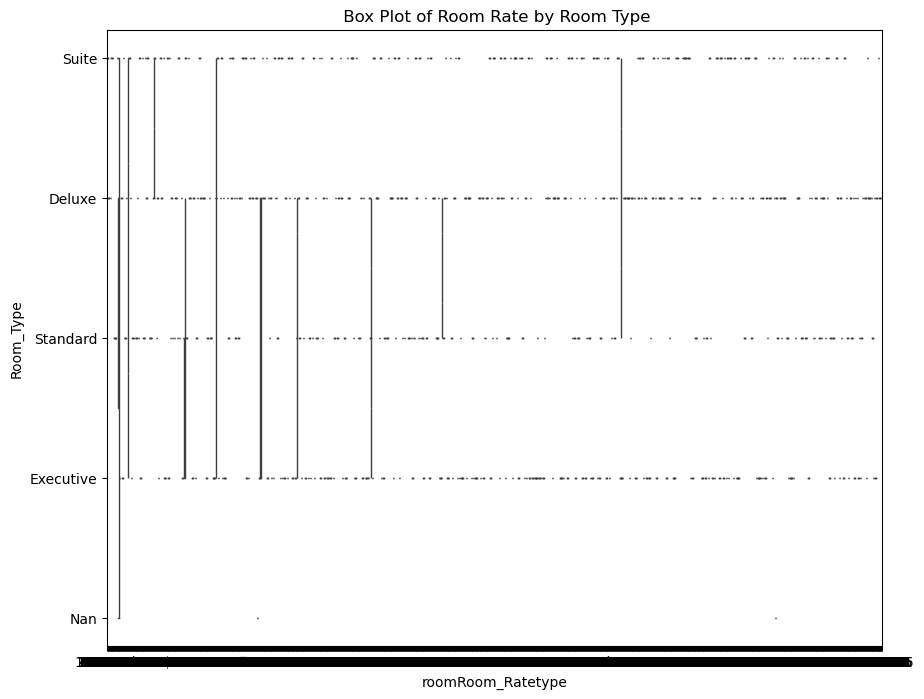

In [81]:
#4. Box Plot of Room Rate by Room Type
#What to plot: Spread and outliers of room rates for each room type
#Columns: Room Type, Room Rate
#Required: Both columns cleaned, Room Rate numeric
#Easy explanation: Helps see which room type is generally expensive and if there are unusual high/low prices.


plt.figure(figsize=(10,8))

sns.boxplot(
    data=df,
    x="Room_Rate",
    y = "Room_Type"
)

plt.title(" Box Plot of Room Rate by Room Type")
plt.xlabel("roomRoom_Ratetype")
plt.ylabel("Room_Type")
plt.show()

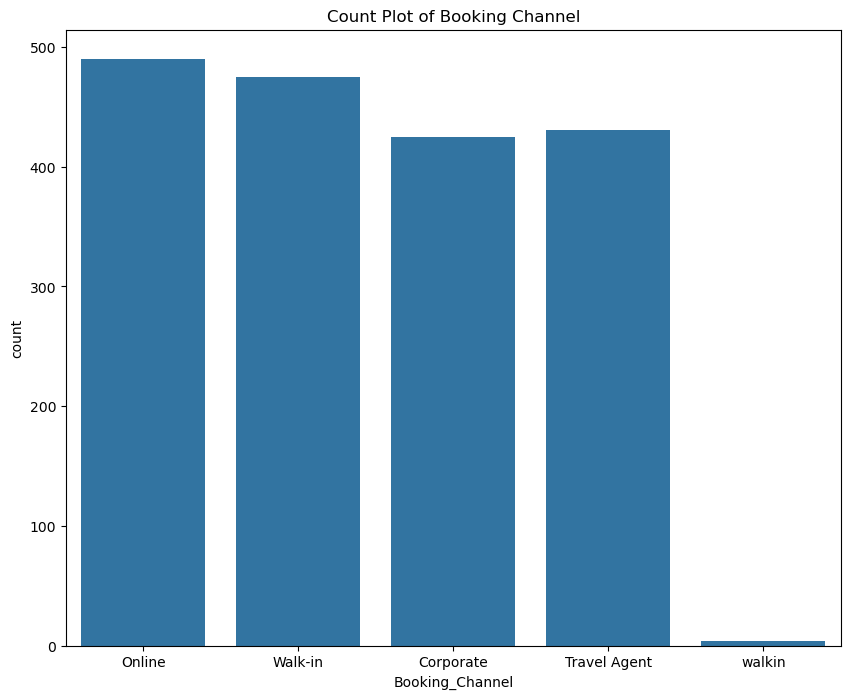

In [85]:
#5. Count Plot of Booking Channel
#What to plot: How many bookings came from each channel
#Columns: Booking Channel
#Required: Channel names standardized (Online, Walk-in, Corporate, Travel Agent)
#Easy explanation: Shows which booking method is most popular.

plt.figure(figsize=(10,8))

sns.countplot(
    data=df,
    x="Booking_Channel",
    #y = "Room_Type"
)

plt.title("Count Plot of Booking Channel")
plt.xlabel("Booking_Channel")
#plt.ylabel()
plt.show()

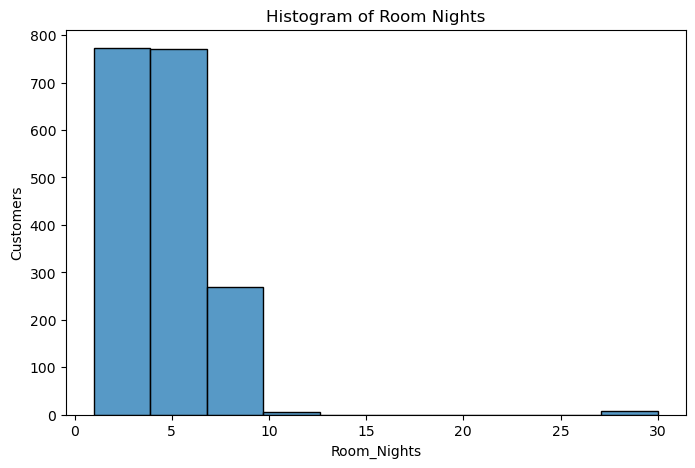

In [86]:
#6. Histogram of Room Nights
#What to plot: How long customers usually stay
#Columns: Room Nights
#Required: Room Nights converted to numbers (remove “3 nights”, “N/A”)
#Easy explanation: Tells whether most people stay 1–2 nights or longer.
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Room_Nights",
    bins= 10
)

plt.title("Histogram of Room Nights")
plt.xlabel("Room_Nights")
plt.ylabel("Customers")
plt.show()

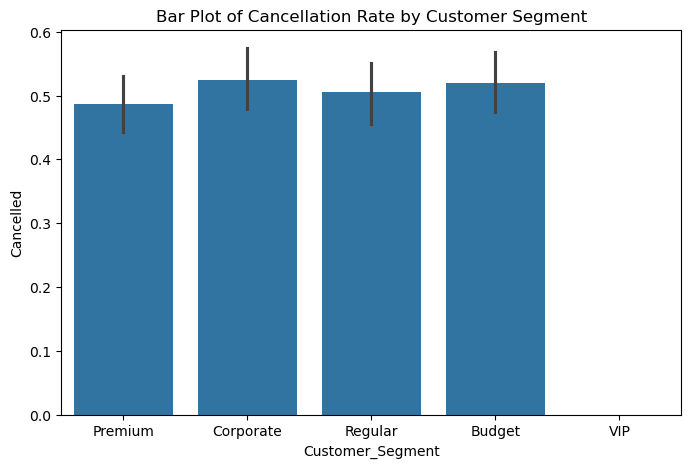

In [87]:
#7. Bar Plot of Cancellation Rate by Customer Segment
#What to plot: Percentage of cancelled bookings in each segment
#Columns: Customer Segment, Cancelled
#Required: Cancelled cleaned to 0/1, Segment standardized
#Easy explanation: Shows which customer group cancels more often.
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Customer_Segment",
    y = "Cancelled"
)

plt.title("Bar Plot of Cancellation Rate by Customer Segment")
plt.xlabel("Customer_Segment")
plt.ylabel("Cancelled")
plt.show()

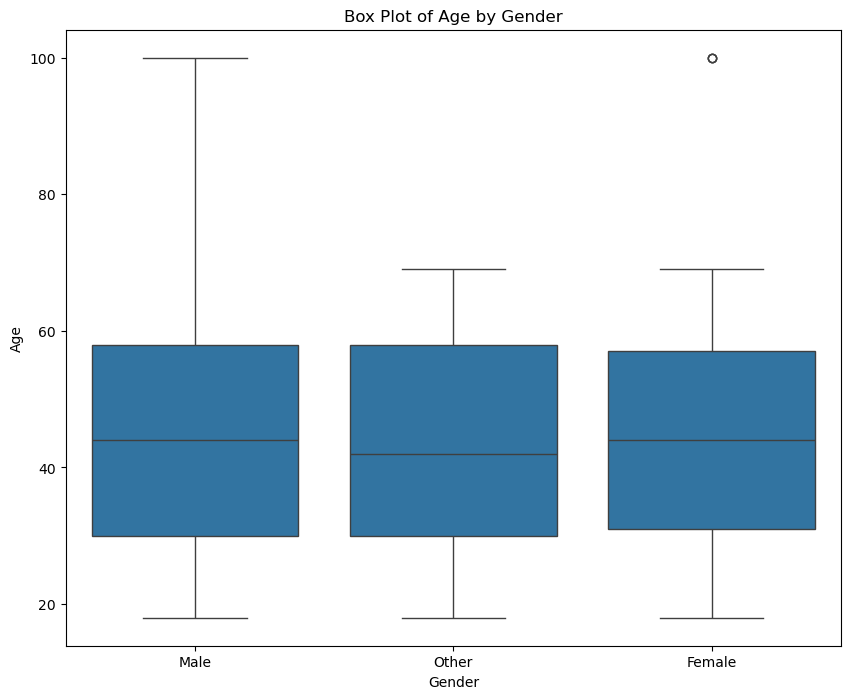

In [88]:
#8. Box Plot of Age by Gender
#What to plot: Age distribution of Male vs Female customers
#Columns: Gender, Age
#Required: Gender standardized (Male/Female/Other), Age numeric
#Easy explanation: Checks if one gender is generally younger or older.

plt.figure(figsize=(10,8))

sns.boxplot(
    data=df,
    x="Gender",
    y = "Age"
)

plt.title("Box Plot of Age by Gender")
plt.xlabel("Gender")
plt.ylabel("Age")
plt.show()

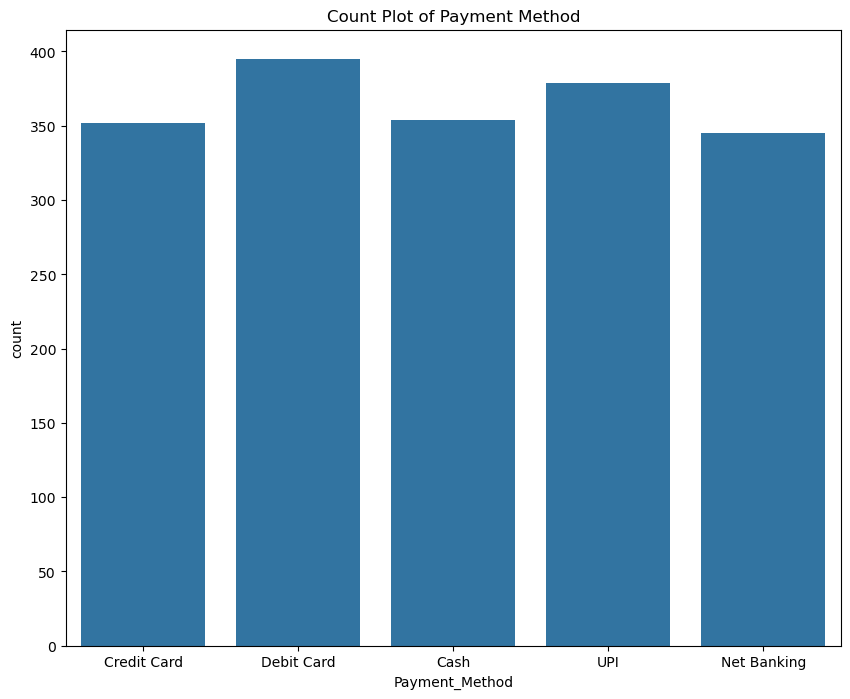

In [89]:
#9. Count Plot of Payment Method
#What to plot: Popularity of different payment methods
#Columns: Payment Method
#Required: Payment Method cleaned and standardized
#Easy explanation: Shows whether Credit Card, UPI, Cash etc. is used more.

plt.figure(figsize=(10,8))

sns.countplot(
    data=df,
    x="Payment_Method",
    #y = "Room_Type"
)

plt.title("Count Plot of Payment Method")
plt.xlabel("Payment_Method")
#plt.ylabel()
plt.show()

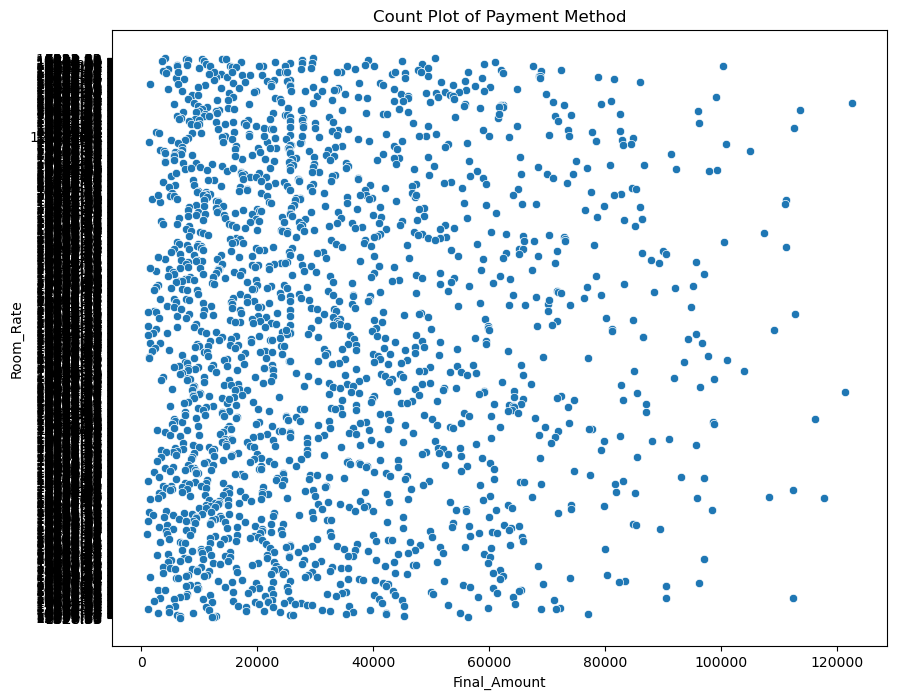

In [90]:
#10. Scatter Plot of Room Rate vs Final Amount
#What to plot: Relationship between room rate and total amount paid
#Columns: Room Rate, Final Amount
#Required: Both columns numeric and cleaned
#Easy explanation: Checks if higher room rates lead to higher final bills.

plt.figure(figsize=(10,8))

sns.scatterplot(
    data=df,
    x="Final_Amount",
    y = "Room_Rate"
)

plt.title("Scatter Plot of Room Rate vs Final Amount")
plt.xlabel("Final_Amount")
plt.ylabel("Room_Rate")
plt.show()

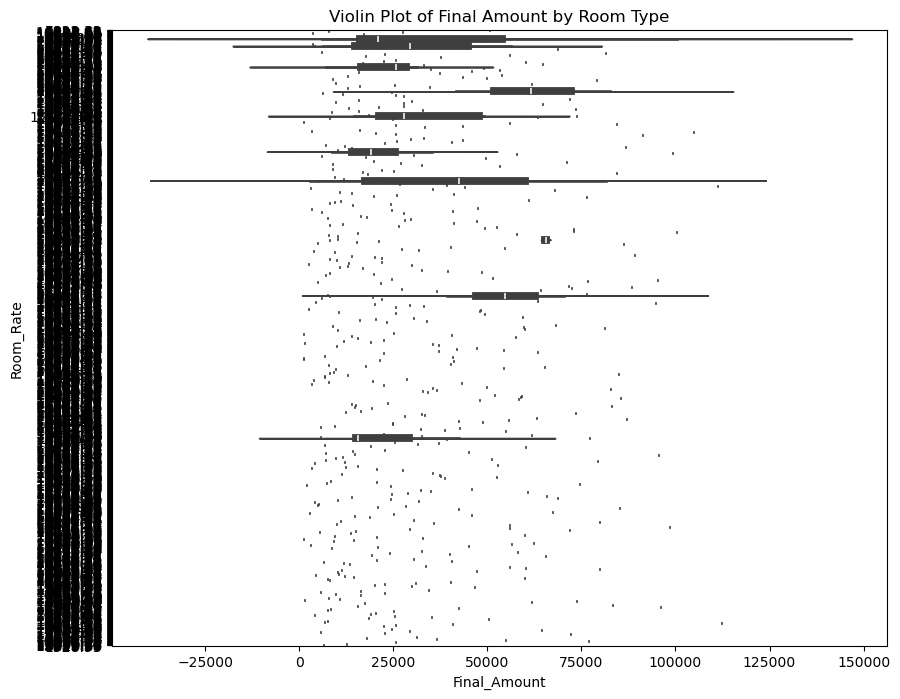

In [91]:
#11. Violin Plot of Final Amount by Room Type
#What to plot: Full distribution of spending for each room type
#Columns: Room Type, Final Amount
#Required: Both columns cleaned
#Easy explanation: Better than box plot – shows the shape of spending (where most values lie).


plt.figure(figsize=(10,8))

sns.violinplot(
    data=df,
    x="Final_Amount",
    y = "Room_Rate"
)

plt.title("Violin Plot of Final Amount by Room Type")
plt.xlabel("Final_Amount")
plt.ylabel("Room_Rate")
plt.show()

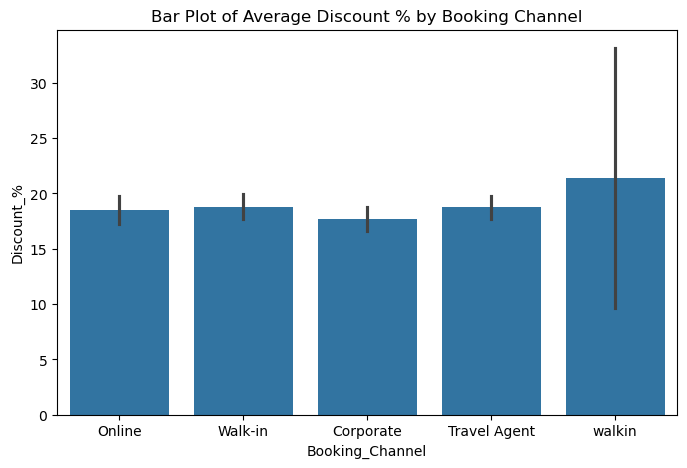

In [92]:
#12. Bar Plot of Average Discount % by Booking Channel
#What to plot: Which channel gives higher average discount
#Columns: Booking Channel, Discount %
#Required: Discount % converted to numbers (0–100)
#Easy explanation: Helps understand discount strategy across channels.


plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Booking_Channel",
    y = "Discount_%"
)

plt.title("Bar Plot of Average Discount % by Booking Channel")
plt.xlabel("Booking_Channel")
plt.ylabel("Discount_%")
plt.show()

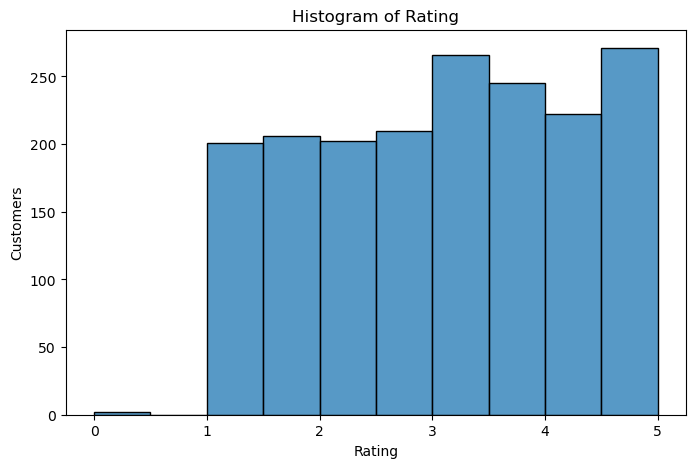

In [93]:
#13. Histogram of Rating
#What to plot: How customers rated their stay
#Columns: Rating
#Required: Rating cleaned (only 1 to 5 values)
#Easy explanation: Shows whether most ratings are high, low, or mixed.

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Rating",
    bins= 10
)

plt.title("Histogram of Rating")
plt.xlabel("Rating")
plt.ylabel("Customers")
plt.show()

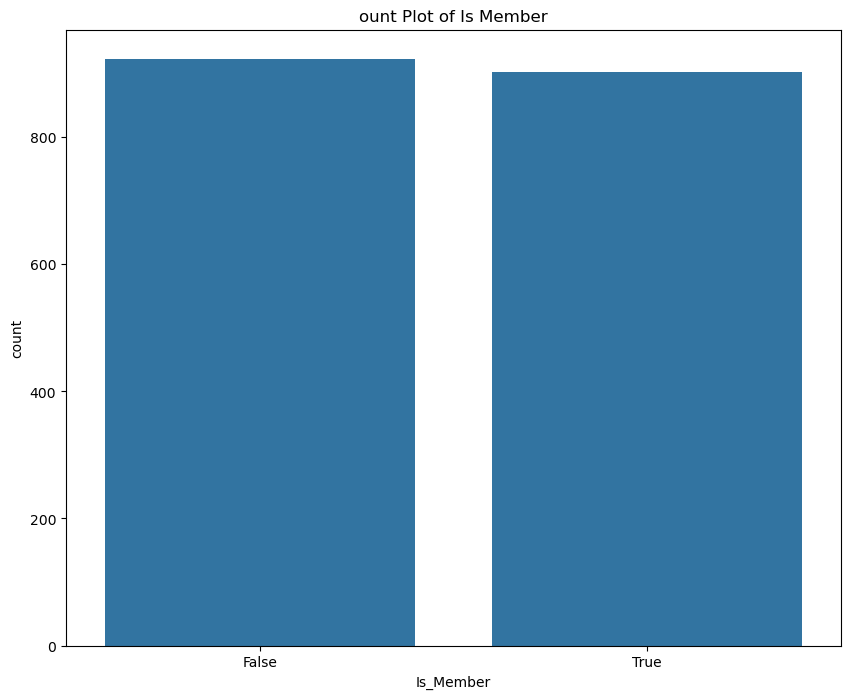

In [94]:
#14. Count Plot of Is Member
#What to plot: How many members vs non-members
#Columns: Is Member
#Required: Converted to Yes/No or 1/0
#Easy explanation: Quick view of member vs non-member ratio.
plt.figure(figsize=(10,8))

sns.countplot(
    data=df,
    x="Is_Member"
    
)

plt.title("ount Plot of Is Member")
plt.xlabel("Is_Member")
plt.show()

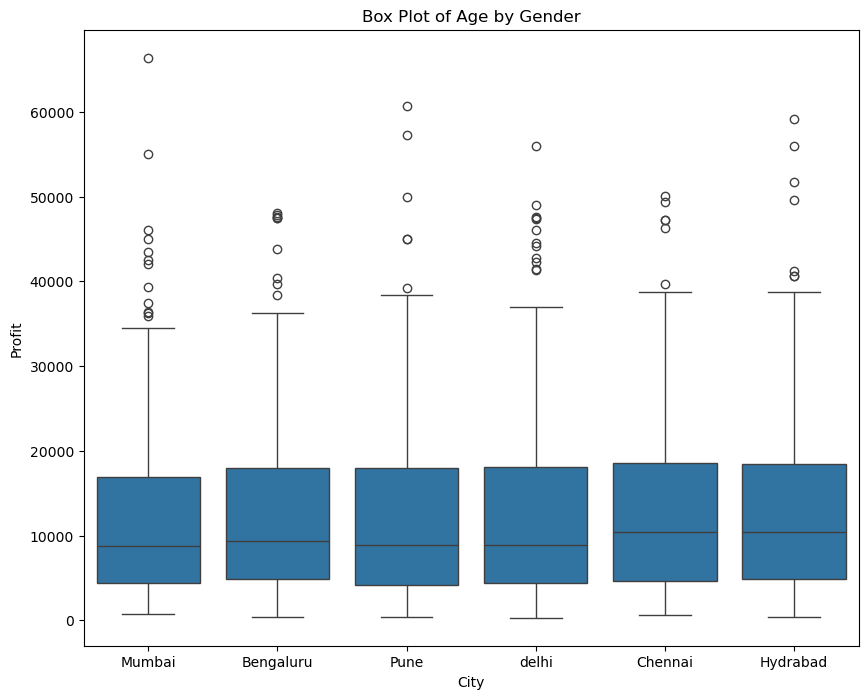

In [95]:
#15. Box Plot of Profit by City
#What to plot: Profit distribution across different cities
#Columns: City, Profit
#Required: City cleaned, Profit numeric
#Easy explanation: Identifies which city is more profitable and if there are extreme profits/losses.

plt.figure(figsize=(10,8))

sns.boxplot(
    data=df,
    x="City",
    y = "Profit"
)

plt.title("Box Plot of Age by Gender")
plt.xlabel("City")
plt.ylabel("Profit")
plt.show()

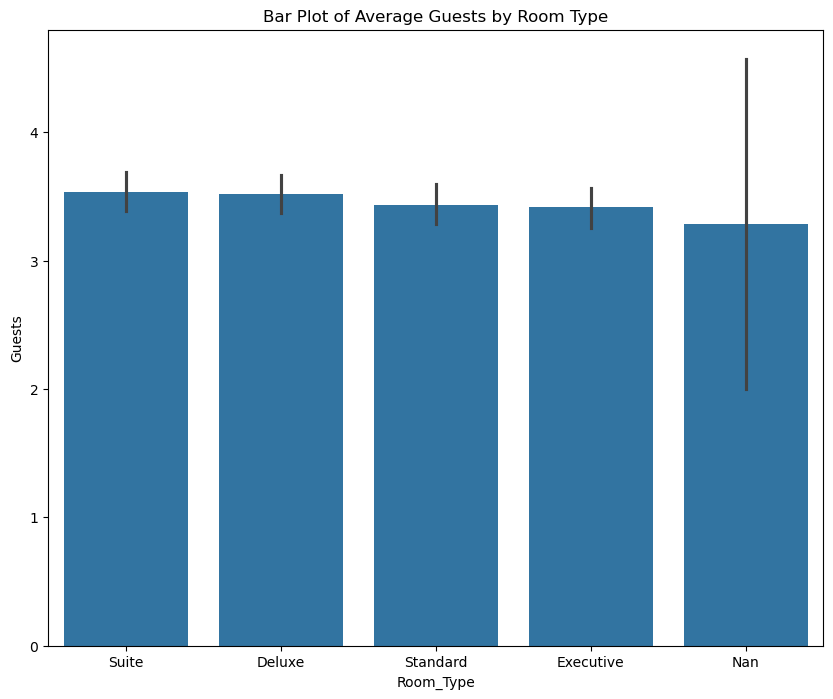

In [96]:
#16. Bar Plot of Average Guests by Room Type
#What to plot: Average number of guests staying in each room type
#Columns: Room Type, Guests
#Required: Both cleaned, Guests numeric
#Easy explanation: Shows whether Suite or Deluxe rooms are used by larger groups.


plt.figure(figsize=(10,8))

sns.barplot(
    data=df,
    x="Room_Type",
    y = "Guests"
)

plt.title("Bar Plot of Average Guests by Room Type")
plt.xlabel("Room_Type")
plt.ylabel("Guests")
plt.show()

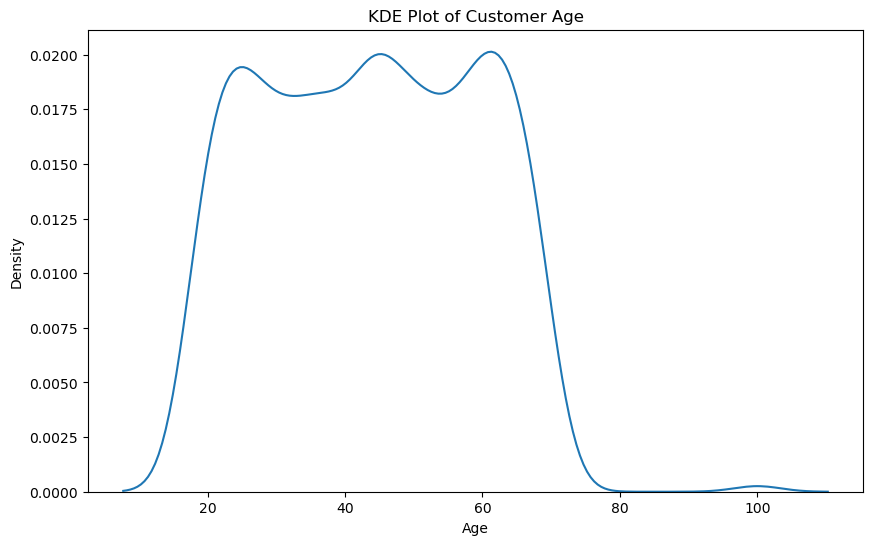

In [101]:
#17. KDE Plot (Density Plot) of Age
#What to plot: Smooth distribution of customer ages
#Columns: Age
#Required: Age numeric and cleaned
#Easy explanation: Similar to histogram but smoother – shows the overall age pattern clearly.

plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=df,
    x="Age"
)

plt.title("KDE Plot of Customer Age")
plt.xlabel("Age")
plt.ylabel("Density")

plt.show()

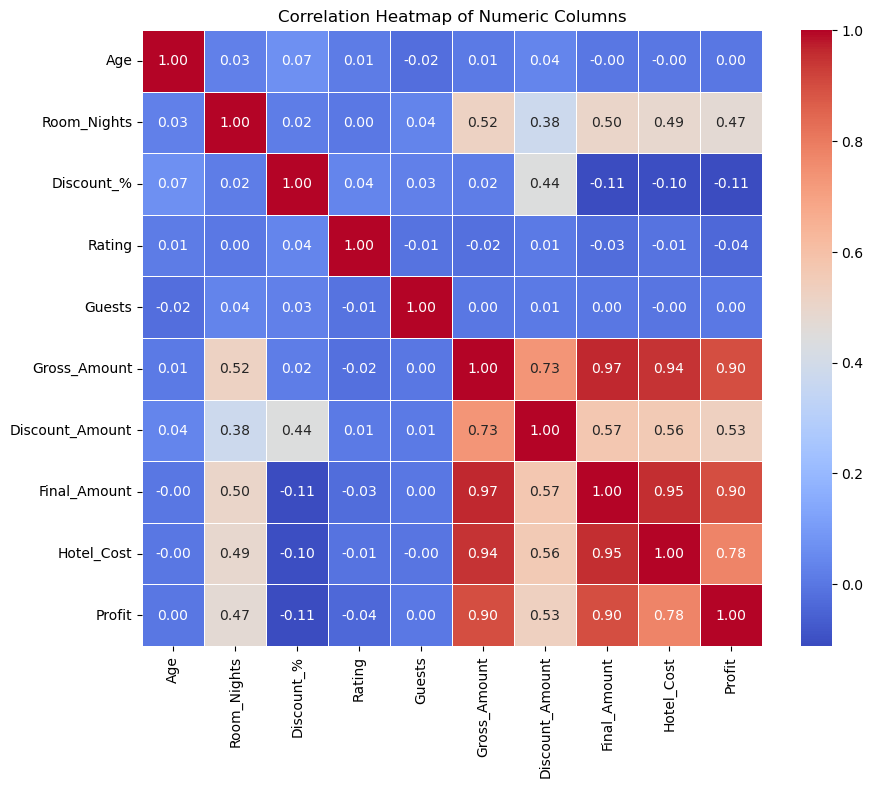

In [107]:
#18. Heatmap of Correlation between Numeric Columns
#What to plot: Relationship strength between numbers like Age, Room Rate, Final Amount,
#Profit, Discount %
#Columns: Select numeric columns only
#Required: All selected columns must be numeric and cleaned
#Easy explanation: Quickly shows which factors move together (positive or negative relation).

numeric_cols = df.select_dtypes(include="number")
corr = numeric_cols.corr()
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numeric Columns")
plt.show()

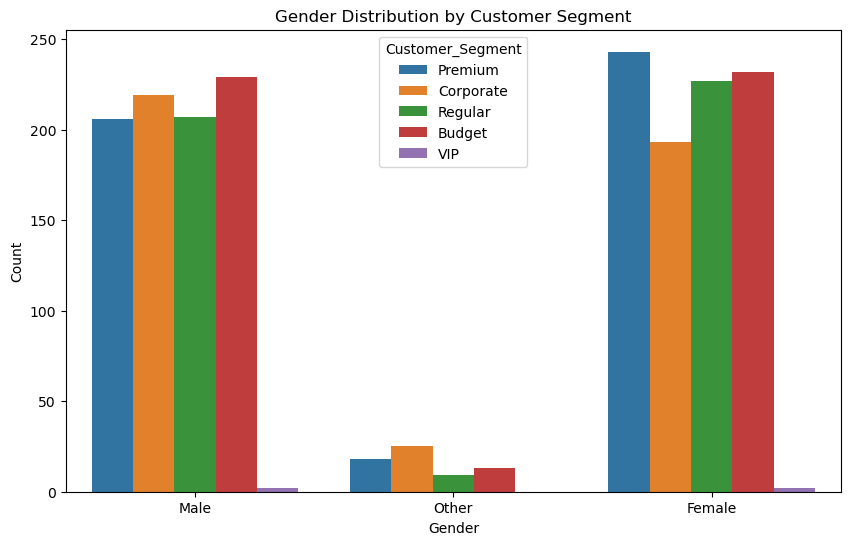

In [111]:
#19. Count Plot of Gender with Hue as Customer Segment
#What to plot: Gender distribution inside each customer segment
#Columns: Gender, Customer Segment
#Required: Both columns cleaned and standardized
#Easy explanation: Shows if Premium segment has more males or females, etc.


plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="Gender",
    hue="Customer_Segment"
)

plt.title("Gender Distribution by Customer Segment")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

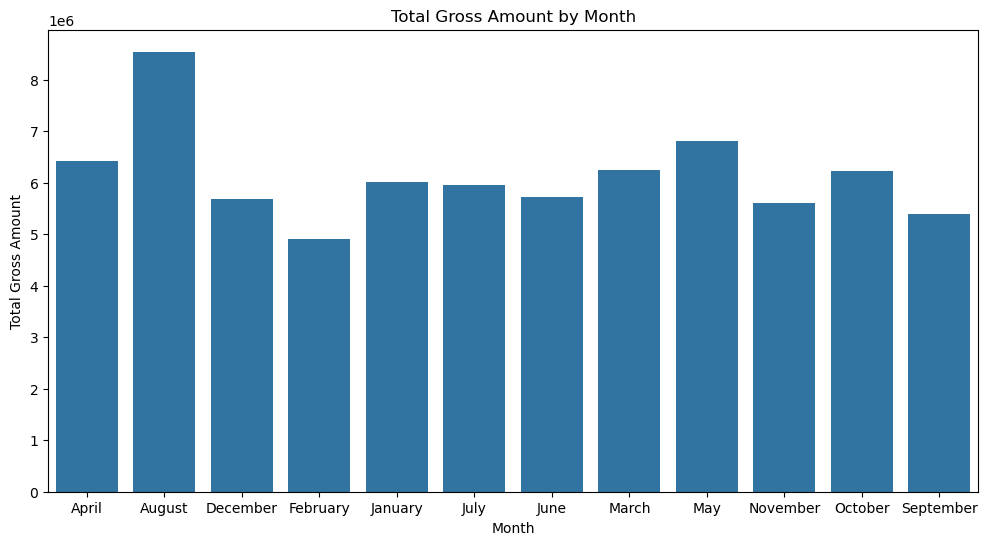

In [119]:
# 20. Bar Plot of Total Gross Amount by Month (from Booking Date)
# What to plot: Total revenue generated in each month
# Columns: Booking Date, Gross Amount
# Required: Booking Date converted to proper date format, then extract month
# Easy explanation: Shows which months are busiest in terms of revenue.

plt.figure(figsize=(12, 6))

sns.barplot(
    data=monthly_gross,
    x="Month",
    y="Gross_Amount"
)

plt.title("Total Gross Amount by Month")
plt.xlabel("Month")
plt.ylabel("Total Gross Amount")
plt.show()